<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 8</b></center>    
<pre>    

# import necessary libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Import diabetes.csv data ser using pandas

In [106]:
df = pd.read_csv("diabetes.csv")

In [107]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic
5,5,116,74,0,0,25.6,0.201,30,Non Diabetic
6,3,78,50,32,88,31.0,0.248,26,Diabetic
7,10,115,0,0,0,35.3,0.134,29,Non Diabetic
8,2,197,70,45,543,30.5,0.158,53,Diabetic
9,8,125,96,0,0,0.0,0.232,54,Diabetic


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    str    
dtypes: float64(2), int64(6), str(1)
memory usage: 54.1 KB


# Check the distribution of the target

In [109]:
df["Outcome"].value_counts()

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64

# Replace zeros with NaN for specific columns

In [118]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [119]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df[cols] = df[cols].replace(0, np.nan)

In [120]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,Diabetic
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,Non Diabetic
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,Diabetic
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,Non Diabetic
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Diabetic


In [121]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Check for missing values

In [122]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Fill missing values with median

In [123]:
#for col in cols:
#    df[col].fillna(df[col].median(), inplace=True)
# Above Code Can Throw Error

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [124]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Visualize Distributions

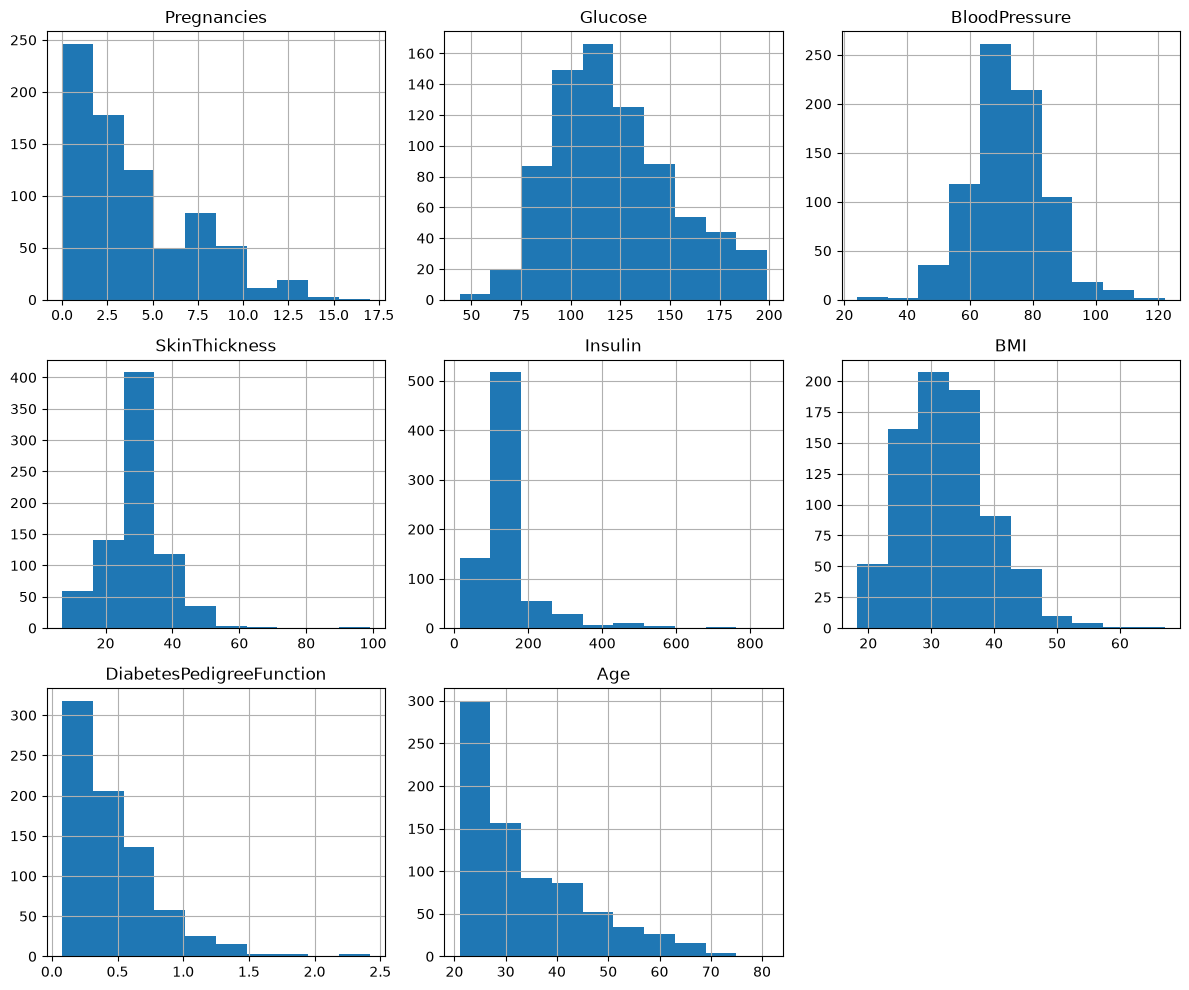

In [125]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Convert Target data into interger code

In [126]:
df["Outcome"].unique()

<StringArray>
['Diabetic', 'Non Diabetic']
Length: 2, dtype: str

In [127]:
le = LabelEncoder()
df["Outcome"] = le.fit_transform(df["Outcome"])

In [54]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,0
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,1
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,1
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,1
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,0


# Divide the data into input and output

In [55]:
X = df.drop("Outcome", axis=1)

In [56]:
y = df["Outcome"]

# Splitting the dataset into the Training set and Test set

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,72.0,29.0,125.0,32.3,0.304,21
618,9,112.0,82.0,24.0,125.0,28.2,1.282,50
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22
294,0,161.0,50.0,29.0,125.0,21.9,0.254,65
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46
...,...,...,...,...,...,...,...,...
71,5,139.0,64.0,35.0,140.0,28.6,0.411,26
106,1,96.0,122.0,29.0,125.0,22.4,0.207,27
270,10,101.0,86.0,37.0,125.0,45.6,1.136,38
435,0,141.0,72.0,29.0,125.0,42.4,0.205,29


In [60]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
668,6,98.0,58.0,33.0,190.0,34.0,0.430,43
324,2,112.0,75.0,32.0,125.0,35.7,0.148,21
624,2,108.0,64.0,29.0,125.0,30.8,0.158,21
690,8,107.0,80.0,29.0,125.0,24.6,0.856,34
473,7,136.0,90.0,29.0,125.0,29.9,0.210,50
...,...,...,...,...,...,...,...,...
355,9,165.0,88.0,29.0,125.0,30.4,0.302,49
534,1,77.0,56.0,30.0,56.0,33.3,1.251,24
344,8,95.0,72.0,29.0,125.0,36.8,0.485,57
296,2,146.0,70.0,38.0,360.0,28.0,0.337,29


In [81]:
y_train

60     1
618    0
346    1
294    1
231    0
      ..
71     1
106    1
270    0
435    0
102    1
Name: Outcome, Length: 614, dtype: int64

# Create Model

In [88]:
model = DecisionTreeClassifier(max_depth=2, random_state=42)

In [79]:
for depth in range(1,11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    print(f"Depth: {depth} | Train Accuracy: {model.score(X_train, y_train):.3f} | Test Accuracy: {model.score(X_test, y_test):.3f}")

Depth: 1 | Train Accuracy: 0.735 | Test Accuracy: 0.740
Depth: 2 | Train Accuracy: 0.770 | Test Accuracy: 0.773
Depth: 3 | Train Accuracy: 0.775 | Test Accuracy: 0.760
Depth: 4 | Train Accuracy: 0.803 | Test Accuracy: 0.708
Depth: 5 | Train Accuracy: 0.837 | Test Accuracy: 0.727
Depth: 6 | Train Accuracy: 0.871 | Test Accuracy: 0.727
Depth: 7 | Train Accuracy: 0.894 | Test Accuracy: 0.721
Depth: 8 | Train Accuracy: 0.912 | Test Accuracy: 0.721
Depth: 9 | Train Accuracy: 0.932 | Test Accuracy: 0.747
Depth: 10 | Train Accuracy: 0.948 | Test Accuracy: 0.708


# Fitting DecisionTreeClassifier   on dataset

In [89]:
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

# Display Decision Tree

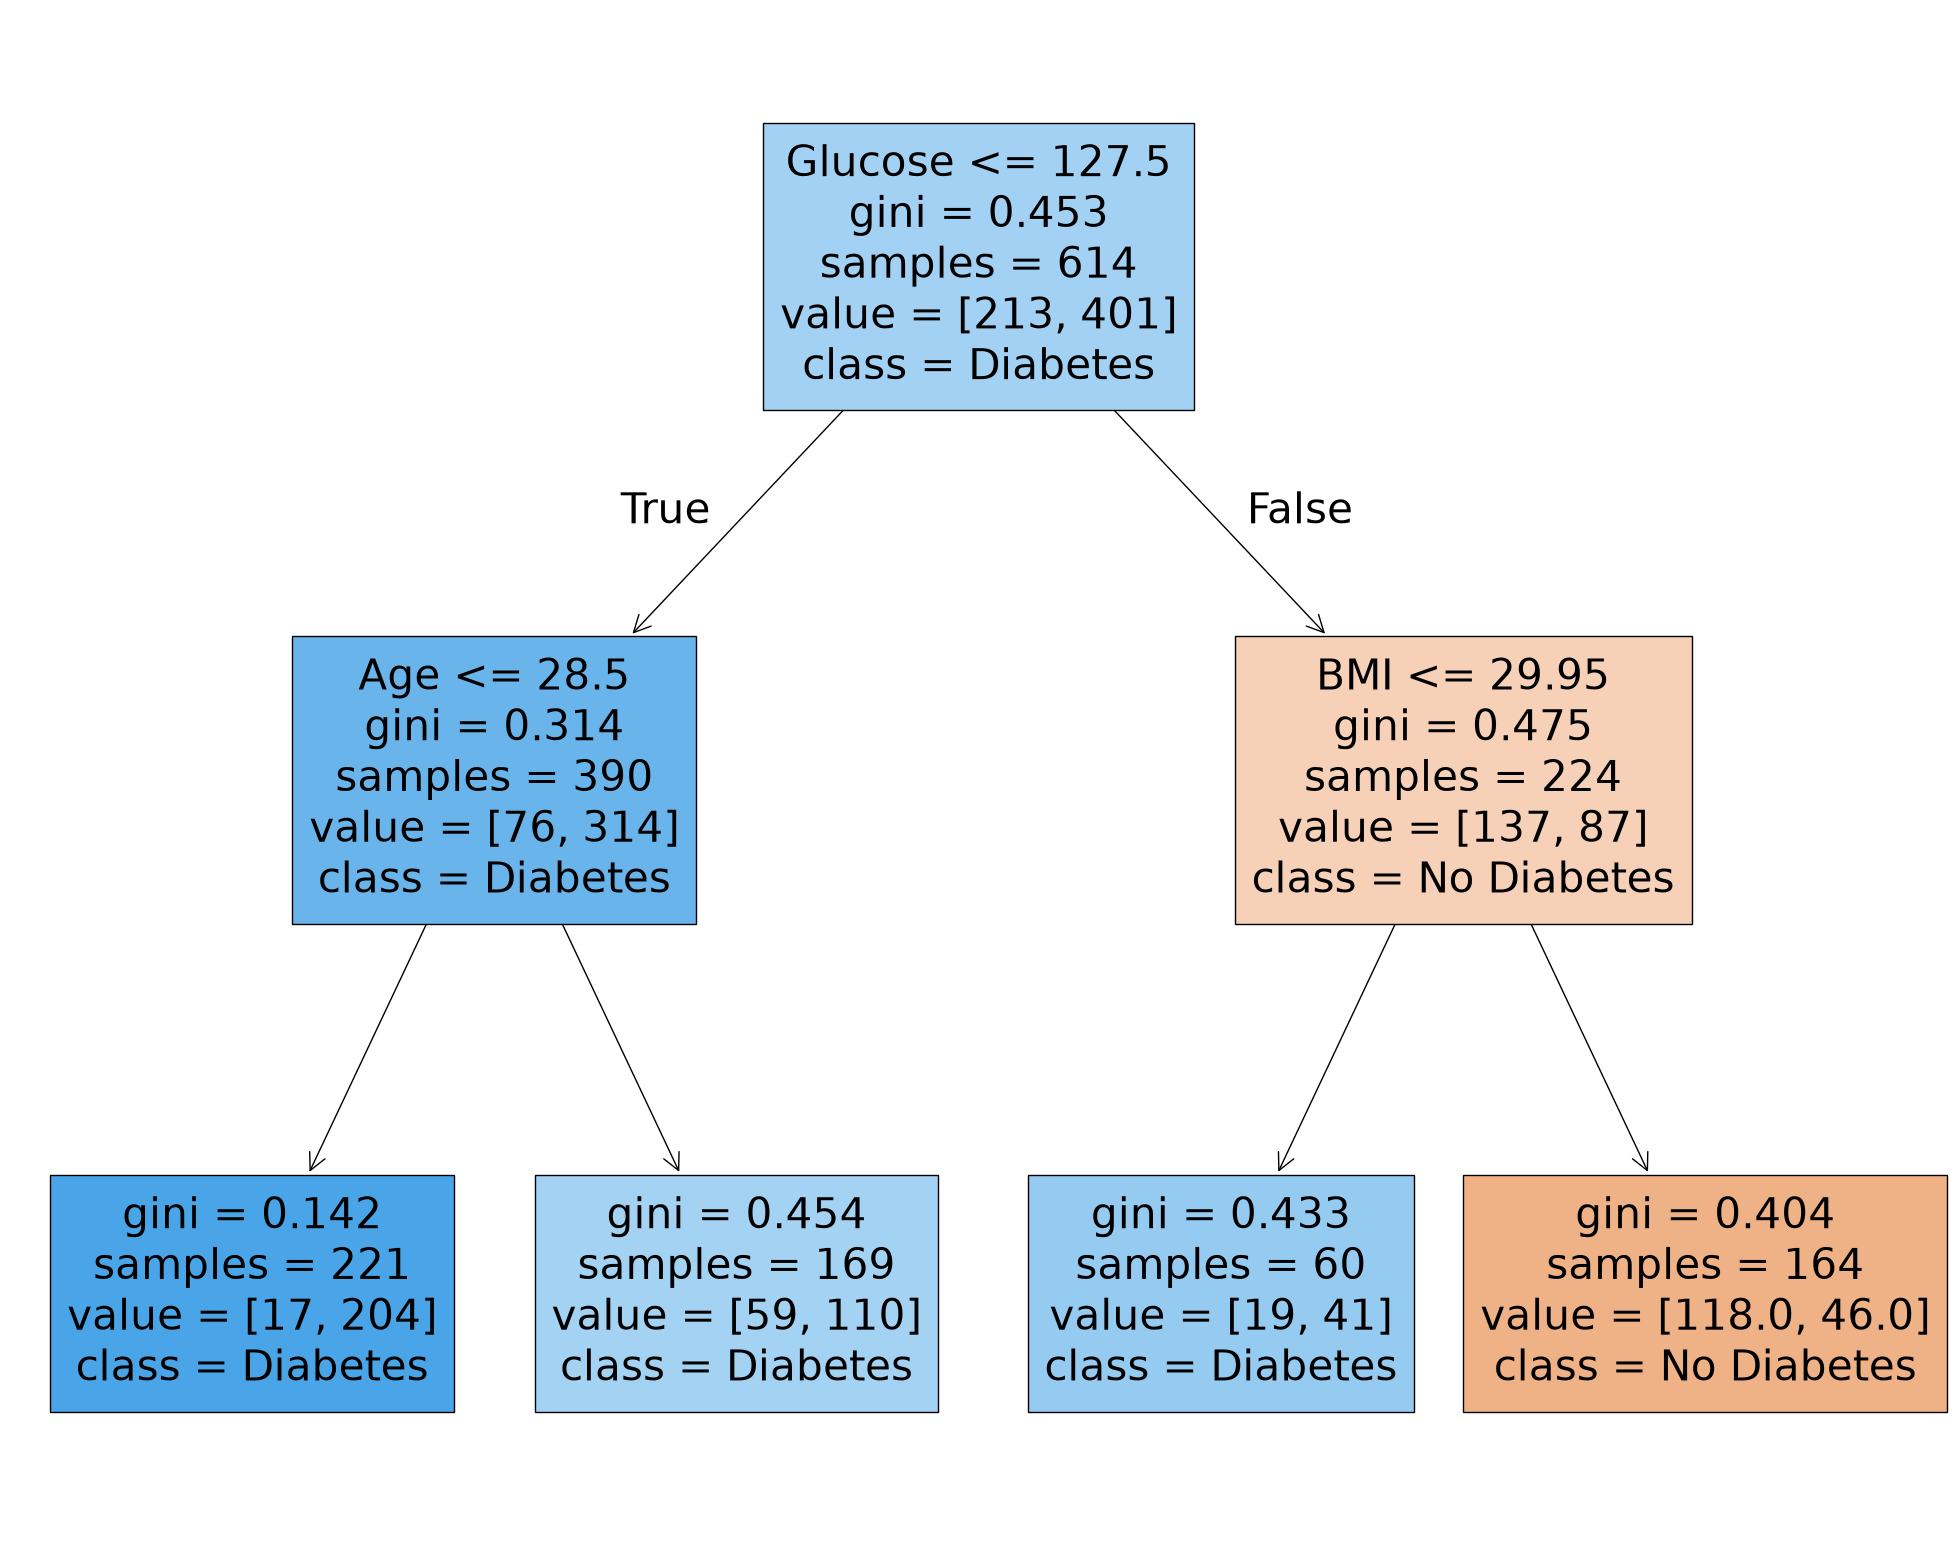

In [90]:
fig = plt.figure(figsize=(25,20))
plot_tree(model, feature_names=X.columns, class_names=["No Diabetes", "Diabetes"], filled=True)
plt.show()

# Predict the x_test 

In [91]:
y_pred = model.predict(X_test)

In [92]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1])

# Display Training Accuracy

In [97]:
train_pred = model.predict(X_train)

In [103]:
train_acc = accuracy_score(y_train, train_pred)

In [104]:
print("Train Accuracy :", train_acc)

Train Accuracy : 0.7703583061889251


# Display Test Accuracy

In [100]:
test_acc = accuracy_score(y_test,y_pred)

In [101]:
print("Test Accuracy :", test_acc)

Test Accuracy : 0.7727272727272727
